✅ Connected to database
✅ Loaded 418 farm-day rows
   Farms: 10
   Date range: 2025-04-13 → 2026-04-03
   Rows with weather data: 418

Shape: (418, 25)
✅ Feature engineering complete
   Total features: 54

All columns:
   1. FarmId
   2. FarmName
   3. Date
   4. CellCount
   5. NDVI
   6. NDMI
   7. Risk
   8. RiskMin
   9. RiskMax
  10. RiskStd
  11. HighRiskCells
  12. MedRiskCells
  13. LowRiskCells
  14. TempMax
  15. TempMin
  16. Rainfall
  17. Humidity
  18. ET0
  19. WindSpeed
  20. DroughtRisk
  21. FloodRisk
  22. FungalRisk
  23. HeatStressRisk
  24. Month
  25. DayOfWeek
  26. NDVI_lag1
  27. NDMI_lag1
  28. Risk_lag1
  29. NDVI_lag2
  30. NDMI_lag2
  31. Risk_lag2
  32. NDVI_lag3
  33. NDMI_lag3
  34. Risk_lag3
  35. NDVI_roll3
  36. NDVI_roll5
  37. Risk_roll3
  38. NDVI_trend
  39. Risk_trend
  40. NDVI_change
  41. NDMI_change
  42. Risk_change
  43. Rain_7d
  44. Rain_14d
  45. Hum_3d_avg
  46. Temp_3d_avg
  47. DryStreak
  48. Season
  49. IsHarvestSeason
  50. IsFlu

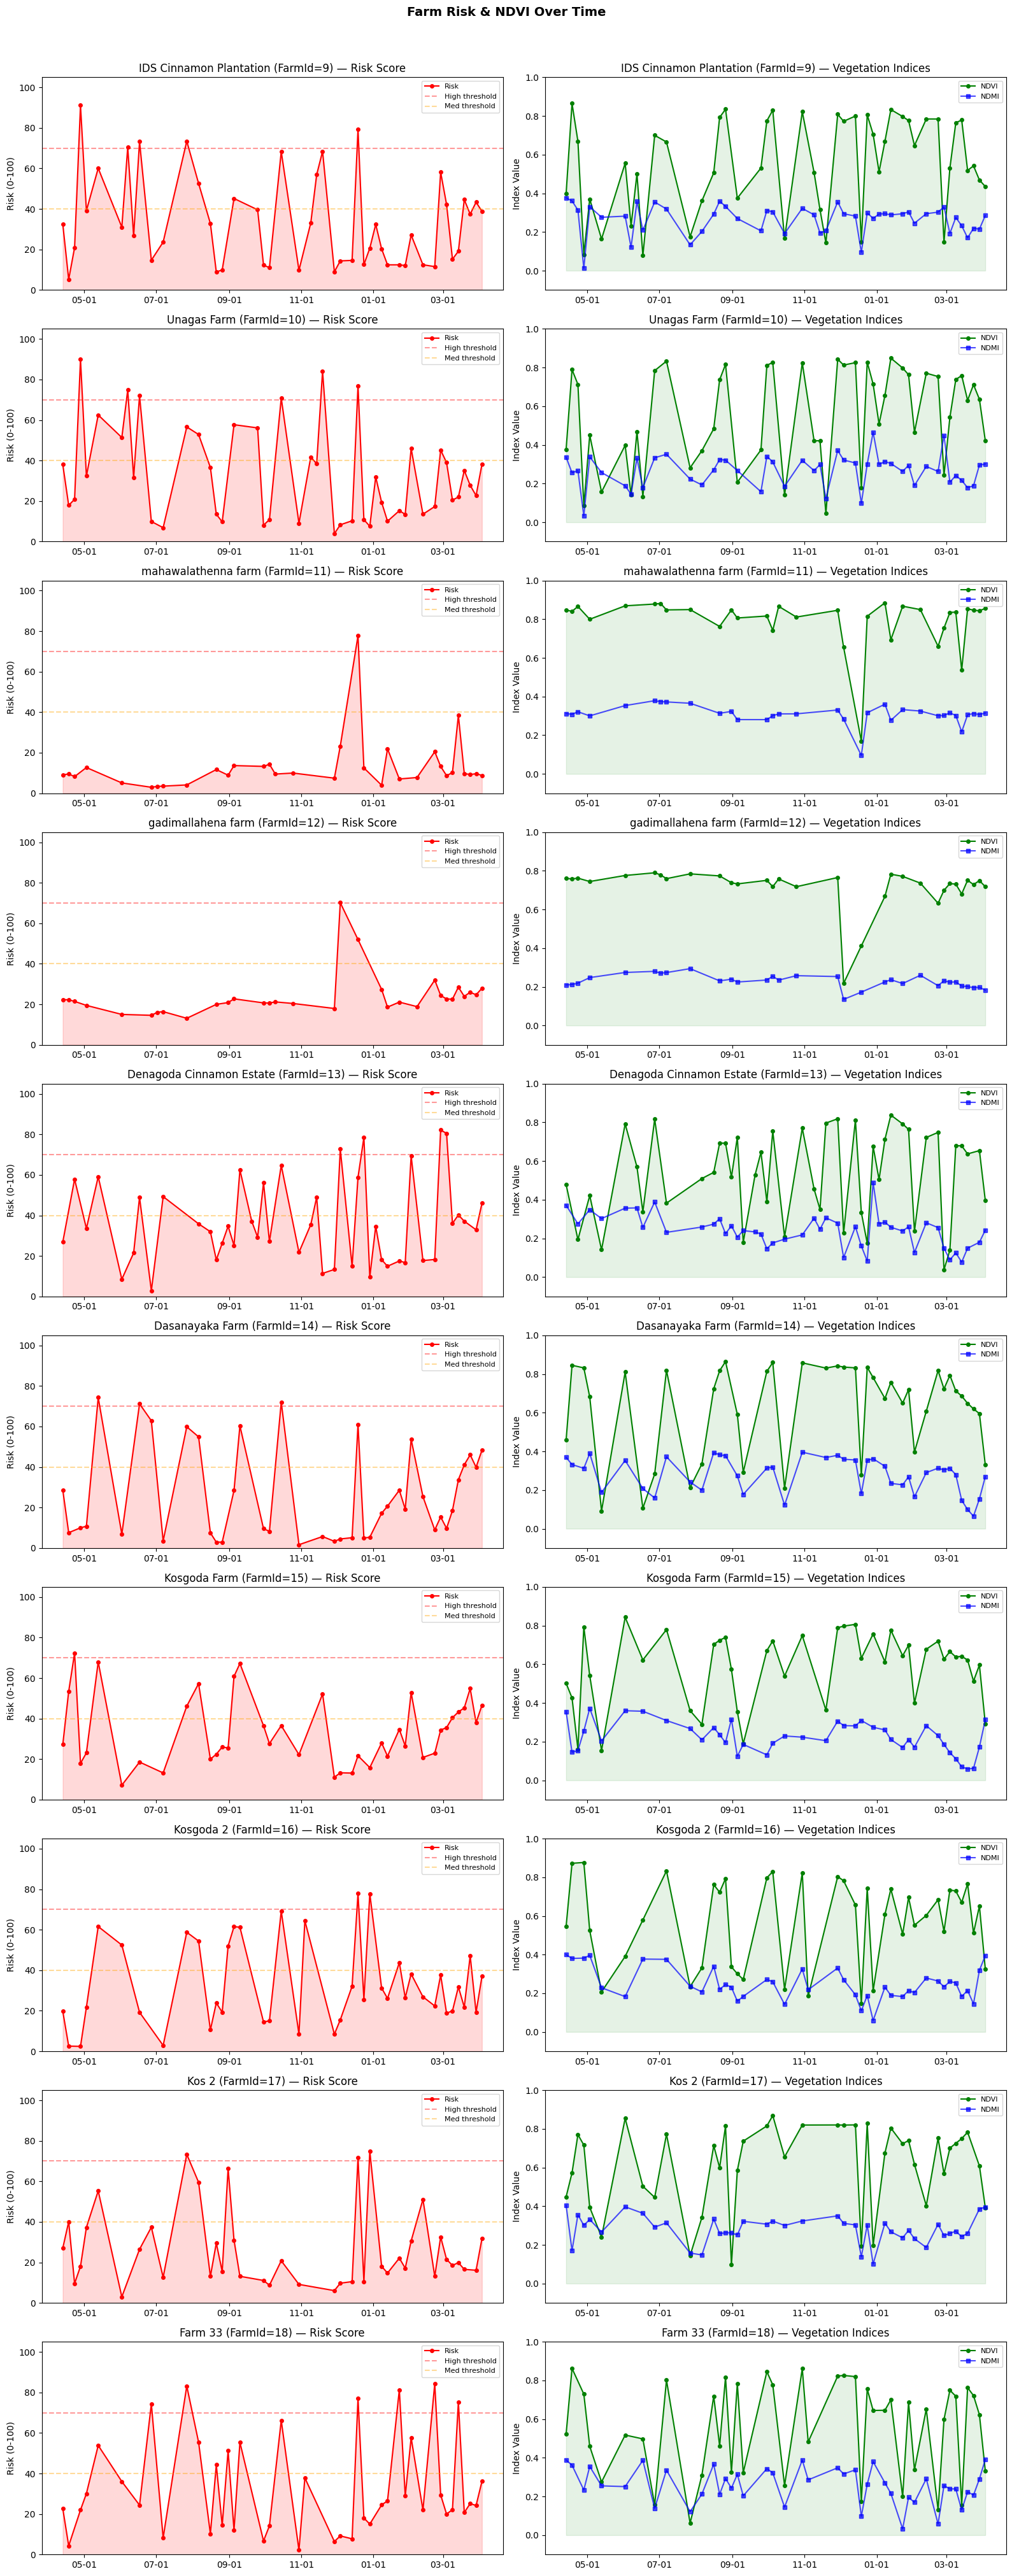

✅ Chart saved: farm_risk_ndvi_timeline.png
Rows with both satellite + weather: 418


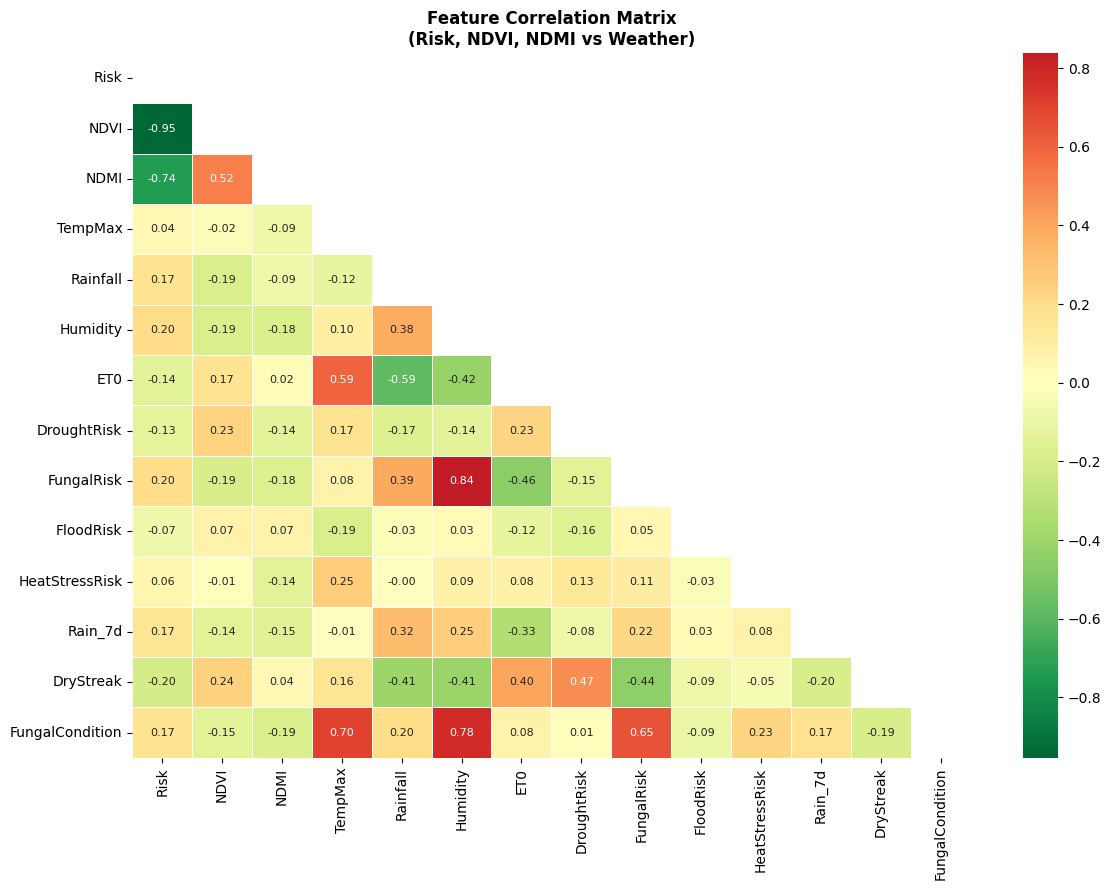

✅ Saved: correlation_heatmap.png
✅ Final ML dataset ready
   Total rows:    408
   Feature count: 36
   Target:        Risk

Sample rows:
✅ Saved:
   farm_ml_dataset.csv  — cleaned features + target (for model training)
   farm_full_dataset.csv — all columns including diagnostics

SUMMARY
  Farms:             10
  Snapshots:         408
  Features:          36
  Target:            Risk (0-100)
  Date range:        2025-04-18 → 2026-04-03

  ✅ Ready for model training in next notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pyodbc
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ── DB connection ─────────────────────────────────────────────────────────────
DB_SERVER = "VIDURA\\SQLEXPRESS;"
DB_NAME   = "SDMS"
DB_USER   = "adminuser"
DB_PASS   = "YOUR_PASSWORD_HERE"   

conn_str = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=VIDURA\\SQLEXPRESS;"
    "DATABASE=SDMS;"
    "Trusted_Connection=yes;"
    "Encrypt=no;"
)

conn = pyodbc.connect(conn_str)
print("✅ Connected to database")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Load raw data from DB
# ══════════════════════════════════════════════════════════════════════════════

# ── Farm-level daily snapshot (averaged across all cells per date) ────────────
farm_daily_sql = "SELECT * FROM vw_FarmDailySnapshot ORDER BY FarmId, Date"

df_raw = pd.read_sql(farm_daily_sql, conn)
df_raw["Date"] = pd.to_datetime(df_raw["Date"])

print(f"✅ Loaded {len(df_raw)} farm-day rows")
print(f"   Farms: {df_raw['FarmId'].nunique()}")
print(f"   Date range: {df_raw['Date'].min().date()} → {df_raw['Date'].max().date()}")
print(f"   Rows with weather data: {df_raw['TempMax'].notna().sum()}")
print(f"\nShape: {df_raw.shape}")
df_raw.head(10)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build all features needed for the AI model.
    Processes each farm separately to avoid cross-farm lag contamination.
    """
    farms = []

    for farm_id, group in df.groupby("FarmId"):
        g = group.copy().sort_values("Date").reset_index(drop=True)

        # ── 1. Lag features (satellite) ──────────────────────────────────────
        for lag in [1, 2, 3]:
            g[f"NDVI_lag{lag}"]  = g["NDVI"].shift(lag)
            g[f"NDMI_lag{lag}"]  = g["NDMI"].shift(lag)
            g[f"Risk_lag{lag}"]  = g["Risk"].shift(lag)

        # ── 2. Rolling means (satellite) ─────────────────────────────────────
        g["NDVI_roll3"]  = g["NDVI"].shift(1).rolling(3,  min_periods=1).mean()
        g["NDVI_roll5"]  = g["NDVI"].shift(1).rolling(5,  min_periods=1).mean()
        g["Risk_roll3"]  = g["Risk"].shift(1).rolling(3,  min_periods=1).mean()

        # ── 3. Trend features ─────────────────────────────────────────────────
        g["NDVI_trend"]  = g["NDVI"] - g["NDVI_roll3"]      # rising/falling NDVI
        g["Risk_trend"]  = g["Risk"] - g["Risk_roll3"]       # rising/falling risk

        # ── 4. Satellite change rate ──────────────────────────────────────────
        g["NDVI_change"] = g["NDVI"].diff()
        g["NDMI_change"] = g["NDMI"].diff()
        g["Risk_change"] = g["Risk"].diff()

        # ── 5. Rolling weather features ───────────────────────────────────────
        g["Rain_7d"]     = g["Rainfall"].rolling(7,  min_periods=1).sum()
        g["Rain_14d"]    = g["Rainfall"].rolling(14, min_periods=1).sum()
        g["Hum_3d_avg"]  = g["Humidity"].rolling(3,  min_periods=1).mean()
        g["Temp_3d_avg"] = g["TempMax"].rolling(3,   min_periods=1).mean()

        # Dry spell — consecutive days with <1mm rain
        rain_arr = g["Rainfall"].fillna(0).values
        dry_streak = np.zeros(len(rain_arr), dtype=int)
        for i in range(1, len(rain_arr)):
            dry_streak[i] = dry_streak[i-1] + 1 if rain_arr[i] < 1.0 else 0
        g["DryStreak"] = dry_streak

        # ── 6. Cinnamon domain features ───────────────────────────────────────
        # Sri Lanka cinnamon seasons:
        # 0=Dry/Harvest (Dec-Feb), 1=PreMonsoon/Flush (Mar-Apr),
        # 2=SWMonsoon (May-Sep), 3=NEMonsoon/Harvest (Oct-Nov)
        season_map = {
            12: 0, 1: 0,  2: 0,
             3: 1, 4: 1,
             5: 2, 6: 2,  7: 2, 8: 2, 9: 2,
            10: 3, 11: 3,
        }
        g["Season"]          = g["Month"].map(season_map)
        g["IsHarvestSeason"] = g["Month"].isin([1, 2, 3, 10, 11]).astype(int)
        g["IsFlushSeason"]   = g["Month"].isin([3, 4]).astype(int)

        # ── 7. Interaction features ───────────────────────────────────────────
        # High humidity + high temp = fungal disease conditions
        g["FungalCondition"]  = (g["Humidity"].fillna(0) / 100.0) * \
                                (g["TempMax"].fillna(0) / 40.0)

        # Drought + heat compound stress
        g["DroughtHeatStress"] = (g["DroughtRisk"].fillna(0) / 100.0) * \
                                 (g["HeatStressRisk"].fillna(0) / 100.0)

        # Satellite health score (NDVI + NDMI combined, higher = healthier)
        g["HealthScore"] = (g["NDVI"] * 0.6 + g["NDMI"] * 0.4)

        # ── 8. High risk cell ratio ───────────────────────────────────────────
        g["HighRiskRatio"] = g["HighRiskCells"] / g["CellCount"].replace(0, 1)

        farms.append(g)

    result = pd.concat(farms, ignore_index=True).sort_values(
        ["FarmId", "Date"]
    ).reset_index(drop=True)

    return result


df = engineer_features(df_raw)

print(f"✅ Feature engineering complete")
print(f"   Total features: {len(df.columns)}")
print(f"\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Data Quality Check
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    "Missing": missing,
    "Pct": missing_pct
}).query("Missing > 0").sort_values("Pct", ascending=False)

print(f"\nMissing values:")
print(missing_df.to_string())

# Per farm summary
print(f"\nPer-farm snapshot count:")
print(df.groupby(["FarmId", "FarmName"])[["Date", "NDVI", "Risk"]].agg({
    "Date": "count",
    "NDVI": "mean",
    "Risk": "mean"
}).rename(columns={"Date": "Snapshots"}).round(3).to_string())

# Risk distribution
print(f"\nRisk distribution (all farms):")
bins   = [0, 40, 70, 100]
labels = ["Low", "Medium", "High"]
df["RiskCategory"] = pd.cut(df["Risk"], bins=bins, labels=labels)
print(df["RiskCategory"].value_counts().to_string())


# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Visualisation: Risk + NDVI over time per farm
# ══════════════════════════════════════════════════════════════════════════════

farm_ids   = df["FarmId"].unique()
farm_names = df.groupby("FarmId")["FarmName"].first()

fig, axes = plt.subplots(len(farm_ids), 2, figsize=(16, 4 * len(farm_ids)))
fig.suptitle("Farm Risk & NDVI Over Time", fontsize=14, fontweight="bold", y=1.01)

for i, fid in enumerate(sorted(farm_ids)):
    fdata = df[df["FarmId"] == fid].sort_values("Date")
    name  = farm_names[fid]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    # Risk
    ax1.plot(fdata["Date"], fdata["Risk"], "r-o", markersize=4, label="Risk")
    ax1.axhline(70, color="red",    linestyle="--", alpha=0.4, label="High threshold")
    ax1.axhline(40, color="orange", linestyle="--", alpha=0.4, label="Med threshold")
    ax1.fill_between(fdata["Date"], fdata["Risk"], alpha=0.15, color="red")
    ax1.set_title(f"{name} (FarmId={fid}) — Risk Score")
    ax1.set_ylabel("Risk (0-100)")
    ax1.set_ylim(0, 105)
    ax1.legend(fontsize=8)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

    # NDVI
    color = "green"
    ax2.plot(fdata["Date"], fdata["NDVI"], "-o", color=color, markersize=4, label="NDVI")
    ax2.plot(fdata["Date"], fdata["NDMI"], "-s", color="blue", markersize=4,
             alpha=0.7, label="NDMI")
    ax2.fill_between(fdata["Date"], fdata["NDVI"], alpha=0.1, color=color)
    ax2.set_title(f"{name} (FarmId={fid}) — Vegetation Indices")
    ax2.set_ylabel("Index Value")
    ax2.set_ylim(-0.1, 1.0)
    ax2.legend(fontsize=8)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

plt.tight_layout()
plt.savefig("farm_risk_ndvi_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: farm_risk_ndvi_timeline.png")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Visualisation: Weather vs Risk correlation
# ══════════════════════════════════════════════════════════════════════════════

weather_features = [
    "TempMax", "Rainfall", "Humidity", "ET0",
    "DroughtRisk", "FungalRisk", "FloodRisk", "HeatStressRisk",
    "Rain_7d", "DryStreak", "FungalCondition"
]

# Only rows that have both satellite and weather
df_joined = df.dropna(subset=["TempMax", "NDVI"])

print(f"Rows with both satellite + weather: {len(df_joined)}")

# Correlation heatmap
corr_cols = ["Risk", "NDVI", "NDMI"] + weather_features
corr_data = df_joined[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(
    corr_data, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn_r", center=0,
    linewidths=0.5, ax=ax, annot_kws={"size": 8}
)
ax.set_title("Feature Correlation Matrix\n(Risk, NDVI, NDMI vs Weather)", 
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: correlation_heatmap.png")


# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Prepare final ML dataset
# ══════════════════════════════════════════════════════════════════════════════

# Features to use for model training
FEATURE_COLS = [
    # Satellite lags (what the farm looked like recently)
    "NDVI_lag1", "NDVI_lag2", "NDVI_lag3",
    "NDMI_lag1", "NDMI_lag2", "NDMI_lag3",
    "Risk_lag1", "Risk_lag2", "Risk_lag3",

    # Satellite trends
    "NDVI_roll3", "NDVI_roll5",
    "Risk_roll3",
    "NDVI_trend", "Risk_trend",
    "NDVI_change", "NDMI_change",

    # Current weather
    "TempMax", "TempMin", "Rainfall", "Humidity", "ET0",

    # Rolling weather
    "Rain_7d", "Rain_14d", "Hum_3d_avg", "Temp_3d_avg", "DryStreak",

    # Weather risk scores
    "DroughtRisk", "FloodRisk", "FungalRisk", "HeatStressRisk",

    # Cinnamon domain features
    "Season", "IsHarvestSeason", "IsFlushSeason",

    # Interaction features
    "FungalCondition", "DroughtHeatStress", "HealthScore",
]

TARGET_COL = "Risk"  # what we want to predict

# Drop rows missing target or critical features
df_model = df.dropna(subset=[TARGET_COL, "NDVI_lag1", "Risk_lag1", "TempMax"])

# Only keep feature columns + identifiers
df_model = df_model[
    ["FarmId", "FarmName", "Date"] + FEATURE_COLS + [TARGET_COL]
].reset_index(drop=True)

print(f"✅ Final ML dataset ready")
print(f"   Total rows:    {len(df_model)}")
print(f"   Feature count: {len(FEATURE_COLS)}")
print(f"   Target:        {TARGET_COL}")
print(f"\nSample rows:")
df_model.head(8)


# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Save joined dataset to CSV (for model notebooks)
# ══════════════════════════════════════════════════════════════════════════════

df_model.to_csv("farm_ml_dataset.csv", index=False)
df.to_csv("farm_full_dataset.csv", index=False)

print("✅ Saved:")
print("   farm_ml_dataset.csv  — cleaned features + target (for model training)")
print("   farm_full_dataset.csv — all columns including diagnostics")

print(f"\n{'=' * 60}")
print("SUMMARY")
print(f"{'=' * 60}")
print(f"  Farms:             {df_model['FarmId'].nunique()}")
print(f"  Snapshots:         {len(df_model)}")
print(f"  Features:          {len(FEATURE_COLS)}")
print(f"  Target:            {TARGET_COL} (0-100)")
print(f"  Date range:        {df_model['Date'].min().date()} → {df_model['Date'].max().date()}")
print(f"\n  ✅ Ready for model training in next notebook")